# DTSC 691 Capstone Project
## Optimal Baseball Pitch Strategy
#### Erik Wagner

## Introduction
Baseball has recently become an analytical goldmine, as showcased in the 2011 film Moneyball, where a team with limited money 
uses data analytics to identify undervalued players. The true creator of this era of analytical baseball is a man named 
Bill James, who authored more than 2 dozen books on the statistics of baseball, coining a term known as sabermetrics. 
His influence in baseball became so widespread that in 2006, Time Magazine named him as one of the 100 most influential people 
in the world, nearly 30 years after his first published book on the topic.

Now every team in professional baseball has entire divisions dedicated to analytics, who are all trying to identify the 
next trend that can give their team an advantage. This use of data science has become such a trend in fact that major league baseball actually has had to ban some of the strategies that data science has provided.


## Goals of the project
With this being the true Golden Age of data science and machine learning in baseball, there is an opportunity to be a part of this in an oft overlooked side of the game. One of the most common machine learning projects that can be seen regarding baseball is a pitch predictor, but rarely, rarely is the other side of the same situation ever seen.

The aim of this project will be to answer the question “What is the optimal strategy for a baseball pitcher in any given situation?” As a secondary goal, clustering will be used to classify pitch type, which will be vital in achieving an optimal strategy.

The aim of the project can more simply be seen as finding the pitch type, horizontal location, and vertical location that will minimize a batter’s opportunity for a successful at-bat in any given situation.


Luckily, Major League Baseball has set up 12 ultra high-speed cameras at each baseball stadium, which are used to create a massive amount of data that the MLB releases every night, commonly referred to as Statcast. This data includes common baseball statistics that are tracked, along with much more detailed pitch-by-pitch analysis, which is what this project will primarily be utilizing. Through various machine learning techniques, including clustering and regression this project will be able to identify a given pitcher’s arsenal (what types of pitches he throws), identify tendencies of both hitters and pitchers in various states, and ultimately use those to identify the best strategies for a pitcher.

The idea of an optimal pitch will depend on many factors. But, ultimately, the optimal strategies for a pitcher will be decided by two main factors; the pitch type and the location of the pitch. These factors are important independently, but generally will have to work jointly together.


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from pybaseball import statcast
from pybaseball import pitching_stats
from pybaseball import batting_stats
from pybaseball import statcast_batter
from pybaseball import batting_stats_bref
from pybaseball import statcast_pitcher
from pybaseball.statcast_pitcher_spin import statcast_pitcher_spin
from pybaseball import playerid_lookup
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, mean_squared_error, mean_absolute_error
import sys
from sklearn.linear_model import LinearRegression, Lasso
from catboost import CatBoostRegressor
import seaborn as sns
from sklearn.metrics import silhouette_score
plt.style.use('ggplot')
pd.options.display.max_columns = 100
pd.options.display.min_rows = 100

## Data Description
For this project, I will use pybaseball, which is an open-source package that has scraped data from three of the largest baseball data websites, FanGraphs, Baseball Reference, and Baseball Savant. This package will contain data on every pitch for every game since 2017, which is what I will be utilizing as my data source.

The data gathered is both on a broad scale of major statistics for each player, down to exact information on each specific pitch thrown. While all data has to be considered, the primary data statistics will be include:

In [2]:
'''Use pybaseball to import data. Statcast_pitcher/batter will be used for the main algorithm
while spin_data is going to be used for clustering pitches'''

statcast_data_pitcher = statcast_pitcher('2018-07-01', '2022-10-31', player_id = 477132)
statcast_data_batter = statcast_batter('2018-07-01', '2022-10-31', player_id = 452254)
spin_data = statcast_pitcher_spin('2019-07-01', '2019-09-30', player_id = 477132)

Gathering Player Data
Gathering Player Data
Gathering Player Data


In [3]:
#check shape of first df
statcast_data_pitcher.shape

(10013, 92)

In [4]:
statcast_data_pitcher.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,zone,des,game_type,stand,p_throws,home_team,away_team,type,hit_location,bb_type,balls,strikes,game_year,pfx_x,pfx_z,plate_x,plate_z,on_3b,on_2b,on_1b,outs_when_up,inning,inning_topbot,hc_x,hc_y,tfs_deprecated,tfs_zulu_deprecated,fielder_2,umpire,sv_id,vx0,vy0,vz0,ax,ay,az,sz_top,sz_bot,hit_distance_sc,launch_speed,launch_angle,effective_speed,release_spin_rate,release_extension,game_pk,pitcher.1,fielder_2.1,fielder_3,fielder_4,fielder_5,fielder_6,fielder_7,fielder_8,fielder_9,release_pos_y,estimated_ba_using_speedangle,estimated_woba_using_speedangle,woba_value,woba_denom,babip_value,iso_value,launch_speed_angle,at_bat_number,pitch_number,pitch_name,home_score,away_score,bat_score,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp
0,FF,2022-10-12,92.5,1.56,6.03,"Kershaw, Clayton",592518,477132,field_out,hit_into_play,NaN,NaN,NaN,NaN,9.0,Manny Machado grounds out sharply to first bas...,D,R,L,LAD,SD,X,3.0,ground_ball,0,0,2022,0.26,1.40,0.39,2.11,NaN,NaN,NaN,2,5,Top,139.97,177.31,NaN,NaN,669257,NaN,NaN,-3.559598,-134.540444,-7.268262,3.885678,27.376206,-13.774660,3.66,1.67,72.0,108.8,1.0,92.8,2347.0,6.4,715747,477132,669257,518692,666158,571970,607208,572204,641355,605141,54.14,0.514,0.463,0.0,1.0,0.0,0.0,4.0,39,1,4-Seam Fastball,3,3,3,3,3,3,3,3,Infield shift,Standard,172.0,0.014,-0.099
1,FF,2022-10-12,92.5,1.35,6.04,"Kershaw, Clayton",665742,477132,field_out,hit_into_play,NaN,NaN,NaN,NaN,2.0,Juan Soto lines out sharply to second baseman ...,D,L,L,LAD,SD,X,4.0,line_drive,3,2,2022,0.23,1.48,0.19,2.84,NaN,NaN,NaN,1,5,Top,168.11,139.14,NaN,NaN,669257,NaN,NaN,-3.479357,-134.678133,-5.634310,3.519456,27.676580,-13.062219,3.06,1.47,185.0,100.1,12.0,92.9,2348.0,6.4,715747,477132,669257,518692,666158,571970,607208,572204,641355,605141,54.11,0.917,0.904,0.0,1.0,0.0,0.0,4.0,38,6,4-Seam Fastball,3,3,3,3,3,3,3,3,Infield shift,Standard,171.0,0.021,-0.207
2,SL,2022-10-12,88.0,1.48,6.06,"Kershaw, Clayton",665742,477132,NaN,foul,NaN,NaN,NaN,NaN,8.0,Juan Soto lines out sharply to second baseman ...,D,L,L,LAD,SD,S,NaN,NaN,3,1,2022,-0.47,0.68,-0.20,1.84,NaN,NaN,NaN,1,5,Top,NaN,NaN,NaN,NaN,669257,NaN,NaN,-3.111592,-128.153991,-5.631580,-4.665757,23.311164,-23.764922,3.06,1.47,NaN,NaN,NaN,88.7,2574.0,6.4,715747,477132,669257,518692,666158,571970,607208,572204,641355,605141,54.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38,5,Slider,3,3,3,3,3,3,3,3,Infield shift,Standard,209.0,0.000,-0.049
3,FF,2022-10-12,91.6,1.49,6.01,"Kershaw, Clayton",665742,477132,NaN,called_strike,NaN,NaN,NaN,NaN,8.0,Juan Soto lines out sharply to second baseman ...,D,L,L,LAD,SD,S,NaN,NaN,3,0,2022,-0.08,1.58,-0.05,1.76,NaN,NaN,NaN,1,5,Top,NaN,NaN,NaN,NaN,669257,NaN,NaN,-3.750362,-133.228931,-8.340993,-0.153480,27.756662,-11.707270,3.10,1.47,NaN,NaN,NaN,92.2,2367.0,6.6,715747,477132,669257,518692,666158,571970,607208,572204,641355,605141,53.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38,4,4-Seam Fastball,3,3,3,3,3,3,3,3,Infield shift,Standard,171.0,0.000,-0.052
4,FF,2022-10-12,92.0,1.46,6.06,"Kershaw, Clayton",665742,477132,NaN,ball,NaN,NaN,NaN,NaN,13.0,Juan Soto lines out sharply to second baseman ...,D,L,L,LAD,SD,B,NaN,NaN,2,0,2022,-0.06,1.67,-0.69,1.33,NaN,NaN,NaN,1,5,Top,NaN,NaN,NaN,NaN,669257,NaN,NaN,-5.337565,-133.620758,-9.772655,0.423144,28.165707,-10.264555,3.12,1.47,NaN,NaN,NaN,92.2,2436.0,6.5,715747,477132,669257,518692,666158,571970,607208,572204,641355,605141,54.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38,3,4-Seam Fastball,3,3,3,3,3,3,3,3,Infield shift,Standard,174.0,0.000,0.086


In [5]:
#drop some of the very obviously unneeded columns
exploration_data_pitcher = statcast_data_pitcher.copy()
exploration_data_pitcher.drop(columns=['game_date', 'spin_rate_deprecated','break_angle_deprecated', 'break_length_deprecated', 
                                      'des', 'game_type','home_team','away_team','type','inning_topbot', 'tfs_deprecated',
                                      'tfs_zulu_deprecated','fielder_2','fielder_2.1','fielder_3','fielder_4','fielder_5',
                                      'fielder_6','fielder_7','fielder_7','fielder_9','umpire','spin_dir'], inplace=True)
exploration_data_pitcher.shape

(10013, 70)

In [6]:
#checking for any particular insights
exploration_data_pitcher.describe()

,release_speed,release_pos_x,release_pos_z,batter,pitcher,zone,hit_location,balls,strikes,game_year,pfx_x,pfx_z,plate_x,plate_z,on_3b,on_2b,on_1b,outs_when_up,inning,hc_x,hc_y,sv_id,vx0,vy0,vz0,ax,ay,az,sz_top,sz_bot,hit_distance_sc,launch_speed,launch_angle,effective_speed,release_spin_rate,release_extension,game_pk,pitcher.1,fielder_8,release_pos_y,estimated_ba_using_speedangle,estimated_woba_using_speedangle,woba_value,woba_denom,babip_value,iso_value,launch_speed_angle,at_bat_number,pitch_number,home_score,away_score,bat_score,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,spin_axis,delta_home_win_exp,delta_run_exp
count,9710.000000,9710.000000,9710.000000,10013.000000,10013.0,9710.000000,2490.000000,10013.000000,10013.000000,10013.000000,9710.000000,9710.000000,9710.000000,9710.000000,601.000000,1482.000000,2466.000000,10013.000000,10013.000000,1841.000000,1841.000000,0.0,9710.000000,9710.000000,9710.000000,9710.000000,9710.000000,9710.000000,9710.000000,9710.000000,2836.000000,2901.000000,2902.000000,9805.000000,9596.000000,9623.000000,10013.000000,10013.0,10013.000000,9710.000000,1739.000000,1739.000000,2732.000000,2571.000000,2732.000000,2732.000000,1739.000000,10013.000000,10013.000000,10013.000000,10013.000000,10013.000000,10013.000000,10013.000000,10013.000000,10013.000000,10013.000000,9620.000000,10013.000000,9767.000000
mean,86.458054,1.369742,6.260602,579275.787277,477132.0,9.091658,4.780723,0.767602,0.913313,2019.929192,-0.239322,0.751549,-0.134772,2.054092,578052.525790,584011.138327,574703.435929,0.958554,3.552082,117.781119,127.288756,NaN,-3.135242,-125.769613,-5.398216,-1.793243,25.287812,-21.898443,3.402460,1.604604,136.201340,83.174767,11.846657,84.731290,2527.397040,6.193318,603371.300409,477132.0,623372.126635,54.304634,0.313509,0.351196,0.284956,0.996499,0.174597,0.140190,3.083956,25.828123,2.810347,1.248477,1.581244,0.937581,1.892140,1.593928,1.259762,0.961550,1.892140,215.066216,0.000316,-0.010076
std,5.993481,0.241831,0.138152,70250.152861,0.0,4.156908,2.520010,0.920220,0.825988,1.431091,0.263510,1.019005,0.662548,1.044273,72630.412254,71240.786145,74945.892019,0.817422,1.890006,38.408667,42.952946,NaN,1.686025,8.707531,3.425808,2.808538,3.481361,10.657804,0.184559,0.111378,124.148406,15.691472,32.215176,13.200006,146.281722,0.272417,48730.863112,0.0,31823.539603,0.270072,0.287575,0.381455,0.506583,0.059074,0.379692,0.560936,1.244029,15.750550,1.702823,1.832089,1.864978,1.225560,2.220908,1.864918,1.835509,1.239909,2.220908,59.640785,0.023526,0.219188
min,69.800000,-5.230000,0.110000,405395.000000,477132.0,1.000000,1.000000,0.000000,0.000000,2018.000000,-1.030000,-1.870000,-3.820000,-2.900000,435559.000000,407812.000000,405395.000000,0.000000,1.000000,3.550000,11.330000,NaN,-14.799660,-136.264504,-15.651447,-10.707836,13.932658,-46.128978,2.650000,1.050000,0.000000,10.300000,-85.000000,0.000000,861.000000,3.600000,530688.000000,477132.0,502117.000000,52.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.308000,-0.954000
25%,86.300000,1.220000,6.170000,542303.000000,477132.0,5.000000,2.000000,0.000000,0.000000,2019.000000,-0.430000,0.500000,-0.600000,1.380000,520471.000000,543246.500000,527038.000000,0.000000,2.000000,98.080000,93.780000,NaN,-4.302519,-131.581496,-7.685323,-3.806914,23.191587,-25.867081,3.300000,1.530000,10.000000,72.700000,-12.000000,85.800000,2434.000000,6.000000,565822.000000,477132.0,605141.000000,54.120000,0.073000,0.071500,0.000000,1.000000,0.000000,0.000000,2.000000,12.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,179.000000,0.000000,-0.069000
50%,88.300000,1.390000,6.260000,592885.000000,477132.0,9.000000,5.000000,0.000000,1.000000,2020.000000,-0.250000,0.940000,-0.170000,2.060000,605113.000000,605113.000000,592669.000000,1.000000,3.000000,113.740000,138.790000,NaN,-3.215737,-128.477294,-6.023

In [7]:
#check to see where there are na values
exploration_data_pitcher.isna().sum()

pitch_type                           303
release_speed                        303
release_pos_x                        303
release_pos_z                        303
player_name                            0
batter                                 0
pitcher                                0
events                              7281
description                            0
zone                                 303
stand                                  0
p_throws                               0
hit_location                        7523
bb_type                             8167
balls                                  0
strikes                                0
game_year                              0
pfx_x                                303
pfx_z                                303
plate_x                              303
plate_z                              303
on_3b                               9412
on_2b                               8531
on_1b                               7547
outs_when_up    

In [8]:
#drop some additional columns with many missing values, but not on_3b,on_2b, or on_1b because those can be made binary
exploration_data_pitcher.drop(columns=['hit_location', 'bb_type','hc_x', 'hc_y','estimated_ba_using_speedangle', 
                                      'estimated_woba_using_speedangle', 'woba_value','woba_denom','babip_value',
                                       'iso_value','launch_speed_angle'], inplace=True)

In [9]:
#check for most common pitch thrown
exploration_data_pitcher['pitch_type'].value_counts() 

SL    4120
FF    3955
CU    1577
CH      44
SI      14
Name: pitch_type, dtype: int64

<AxesSubplot:ylabel='Frequency'>

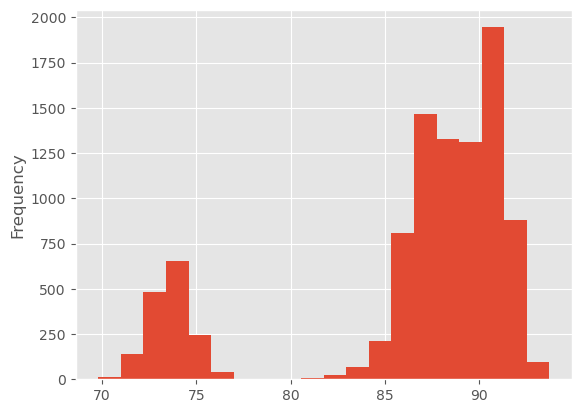

In [10]:
#check frequencies of different velocities
exploration_data_pitcher['release_speed'].plot(kind='hist',bins = 20)

<AxesSubplot:ylabel='Frequency'>

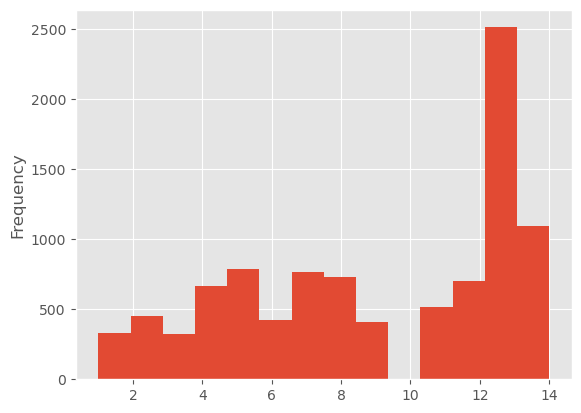

In [11]:
#check frequency that each zone is thrown to
exploration_data_pitcher['zone'].plot(kind='hist',bins=14)

<AxesSubplot:xlabel='release_speed', ylabel='zone'>

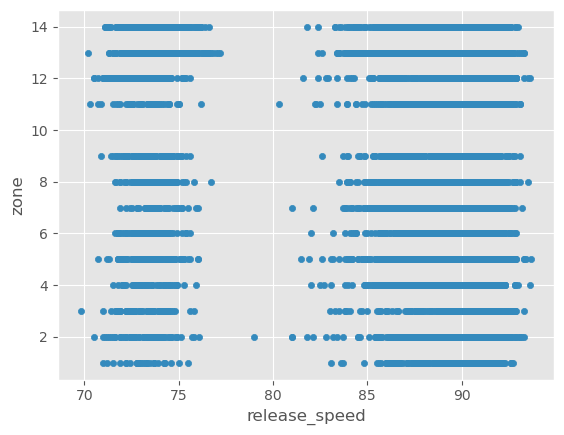

In [12]:
#sort of mimics a histogram above
exploration_data_pitcher.plot(kind='scatter', x='release_speed',y='zone')

<AxesSubplot:title={'center':'release_speed'}, xlabel='pitch_type'>

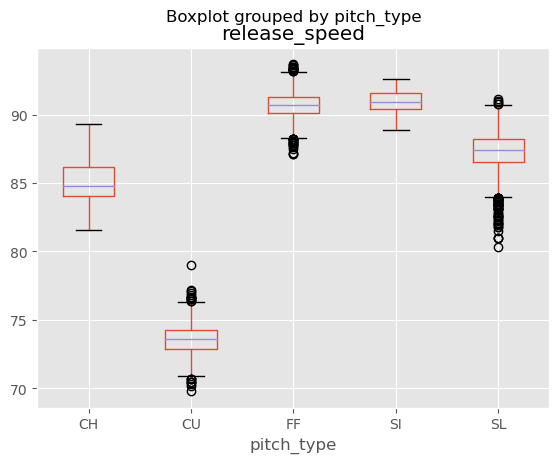

In [13]:
#box plot showing how velocity differs by pitch type
exploration_data_pitcher.boxplot(column='release_speed', by='pitch_type')

In [14]:
corr = exploration_data_pitcher[['release_speed','inning','on_3b','on_2b','on_1b','delta_run_exp','release_spin_rate','outs_when_up']].dropna().corr()

<AxesSubplot:>

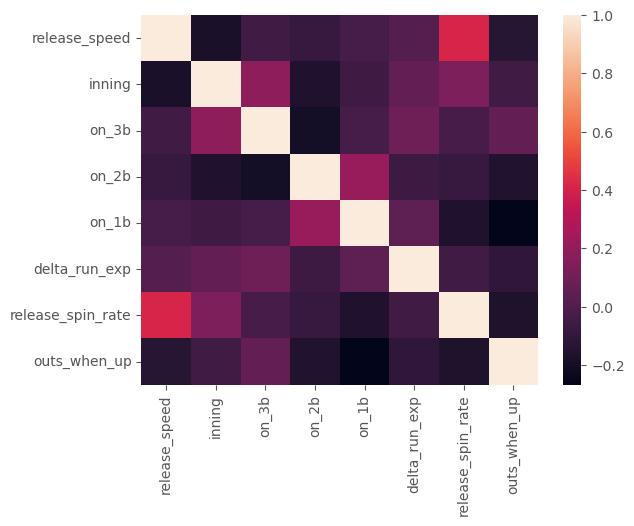

In [15]:
#use correlation above to create heatmap, spin_rate and speed seem correlated
sns.heatmap(corr)

In [16]:
#here I am approaching this very similarly to the pitcher data because it is the same data, but from the other perspective
statcast_data_batter.shape

(2163, 92)

In [17]:
exploration_data_batter = statcast_data_batter.copy()
exploration_data_batter.drop(columns=['game_date', 'spin_rate_deprecated','break_angle_deprecated', 'break_length_deprecated', 
                                      'des', 'game_type','home_team','away_team','type','inning_topbot', 'tfs_deprecated',
                                      'tfs_zulu_deprecated','fielder_2','fielder_2.1','fielder_3','fielder_4','fielder_5',
                                      'fielder_6','fielder_7','fielder_7','fielder_9','umpire','spin_dir'], inplace=True)
exploration_data_batter.shape

(2163, 70)

In [18]:
exploration_data_batter['pitch_type'].value_counts() 

FF    652
SL    411
SI    286
CH    246
CU    202
FC    127
KC     47
ST     20
FS     18
SV      4
FA      2
Name: pitch_type, dtype: int64

<AxesSubplot:>

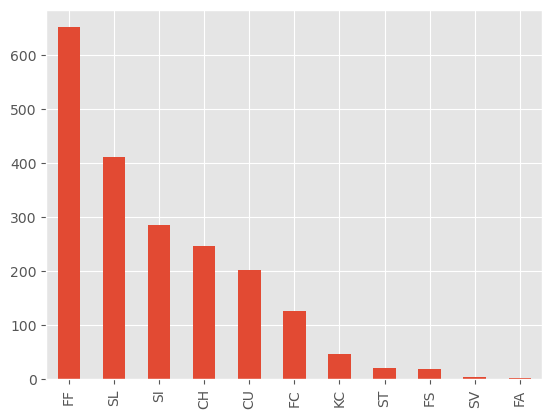

In [19]:
exploration_data_batter['pitch_type'].value_counts().plot(kind='bar')

<AxesSubplot:ylabel='Frequency'>

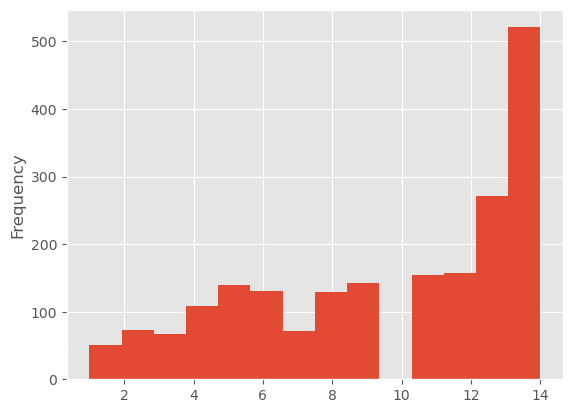

In [20]:
exploration_data_batter['zone'].plot(kind='hist',bins=14)

In [21]:
corr = exploration_data_batter[['release_speed','inning','on_3b','on_2b','on_1b','delta_run_exp','release_spin_rate','outs_when_up']].dropna().corr()

<AxesSubplot:>

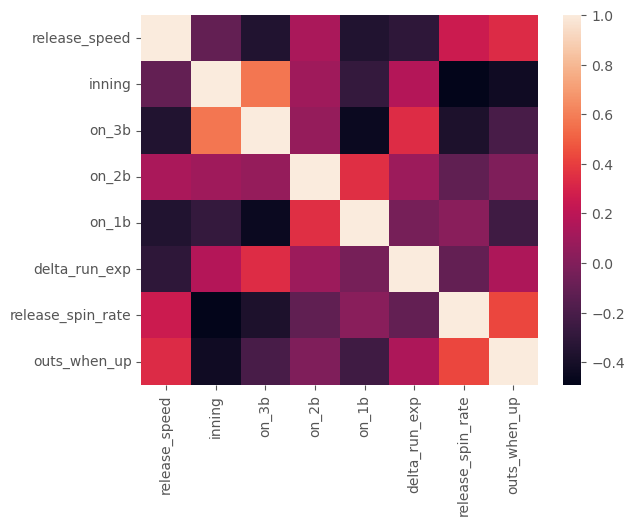

In [22]:
sns.heatmap(corr)

In [23]:
#check spin_data
spin_data.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,zone,des,game_type,stand,p_throws,home_team,away_team,type,hit_location,bb_type,balls,strikes,game_year,pfx_x,pfx_z,plate_x,plate_z,on_3b,on_2b,on_1b,outs_when_up,inning,inning_topbot,hc_x,hc_y,tfs_deprecated,tfs_zulu_deprecated,fielder_2,umpire,sv_id,vx0,vy0,vz0,ax,ay,az,sz_top,sz_bot,hit_distance_sc,launch_speed,launch_angle,effective_speed,release_spin_rate,release_extension,game_pk,pitcher.1,fielder_2.1,fielder_3,fielder_4,fielder_5,fielder_6,fielder_7,fielder_8,fielder_9,release_pos_y,estimated_ba_using_speedangle,estimated_woba_using_speedangle,woba_value,woba_denom,babip_value,iso_value,launch_speed_angle,at_bat_number,pitch_number,pitch_name,home_score,away_score,bat_score,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,Mx,Mz,phi,theta
0,FF,2019-09-29,90.5,1.35,6.19,"Kershaw, Clayton",518516,477132,field_out,hit_into_play,NaN,NaN,NaN,NaN,4,Madison Bumgarner lines out to third baseman J...,R,R,L,SF,LAD,X,5.0,line_drive,3,2,2019,-0.45,1.68,-0.41,2.70,NaN,NaN,NaN,2,5,Bot,95.69,168.33,NaN,NaN,669257,NaN,NaN,-3.421555,-131.602098,-6.251945,-4.353184,29.589289,-11.804447,3.47,1.59,120.0,71.9,12.0,89.9,2492.0,6.1,566551,477132,669257,571970,666158,576397,608369,607461,571771,621035,54.42,0.313,0.282,0.0,1.0,0.0,0.0,2.0,41,7,4-Seam Fastball,0,5,0,5,5,0,0,5,Infield shift,Standard,195,-0.004,-0.138,-5.660538,19.350182,196,44.0
1,FF,2019-09-29,91.1,1.38,6.20,"Kershaw, Clayton",518516,477132,NaN,foul,NaN,NaN,NaN,NaN,2,Madison Bumgarner lines out to third baseman J...,R,R,L,SF,LAD,S,NaN,NaN,3,2,2019,-0.12,1.61,-0.20,2.90,NaN,NaN,NaN,2,5,Bot,NaN,NaN,NaN,NaN,669257,NaN,NaN,-3.712404,-132.569879,-5.828400,-0.639204,28.736324,-12.177657,3.39,1.62,78.0,74.8,81.0,91.1,2420.0,6.3,566551,477132,669257,571970,666158,576397,608369,607461,571771,621035,54.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41,6,4-Seam Fastball,0,5,0,5,5,0,0,5,Infield shift,Standard,184,0.000,0.000,-1.576222,18.638487,185,48.0
2,FF,2019-09-29,89.7,1.42,6.23,"Kershaw, Clayton",518516,477132,NaN,ball,NaN,NaN,NaN,NaN,13,Madison Bumgarner lines out to third baseman J...,R,R,L,SF,LAD,B,NaN,NaN,2,2,2019,-0.14,1.42,-1.52,0.79,NaN,NaN,NaN,2,5,Bot,NaN,NaN,NaN,NaN,669257,NaN,NaN,-6.901063,-130.161455,-10.323340,-0.394645,22.944884,-14.577898,3.43,1.78,NaN,NaN,NaN,89.2,2525.0,5.8,566551,477132,669257,571970,666158,576397,608369,607461,571771,621035,54.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41,5,4-Seam Fastball,0,5,0,5,5,0,0,5,Infield shift,Standard,186,0.000,0.038,-1.865390,16.172299,187,61.0
3,FF,2019-09-29,90.3,1.35,6.23,"Kershaw, Clayton",518516,477132,NaN,called_strike,NaN,NaN,NaN,NaN,4,Madison Bumgarner lines out to third baseman J...,R,R,L,SF,LAD,S,NaN,NaN,2,1,2019,-0.32,1.80,-0.80,2.75,NaN,NaN,NaN,2,5,Bot,NaN,NaN,NaN,NaN,669257,NaN,NaN,-4.642740,-131.218602,-6.374282,-2.529926,29.862425,-10.618777,3.37,1.67,NaN,NaN,NaN,89.3,2424.0,5.9,566551,477132,669257,571970,666158,576397,608369,607461,571771,621035,54.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41,4,4-Seam Fastball,0,5,0,5,5,0,0,5,Infield shift,Standard,190,0.000,-0.033,-4.045363,20.887573,191,37.0
4,FF,2019-09-29,90.1,1.48,6.34,"Kershaw, Clayton",518516,477132,NaN,ball,NaN,NaN,NaN,NaN,12,Madison Bumgarner lines out to third baseman J...,R,R,L,SF,LAD,B,NaN,NaN,1,1,2019,-0.32,1.51,0.14,4.46,NaN,NaN,NaN,2,5,Bot,NaN,NaN,NaN,NaN,669257,NaN,NaN,-2.654158,-131.189924,-1.909716,-3.198396,26.889648,-14.641706,3.49,1.67,NaN,NaN,NaN,90.2,2353.0,6.2,566551,477132,669257,571970,666158,576397,608369,607461,571771,621035,54.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41,3,4-Seam Fastball,0,5,0,5,5,0,0,5,Infield shift,Standard,192,0.000,0.024,-4.088120,17.379120,193,51.0


In [24]:
#correlation, then heatmap
corr1 = spin_data[['release_speed','release_pos_x','release_pos_z','pfx_x','pfx_z','release_spin_rate','Mx','Mz','phi','theta']].dropna().corr()

<AxesSubplot:>

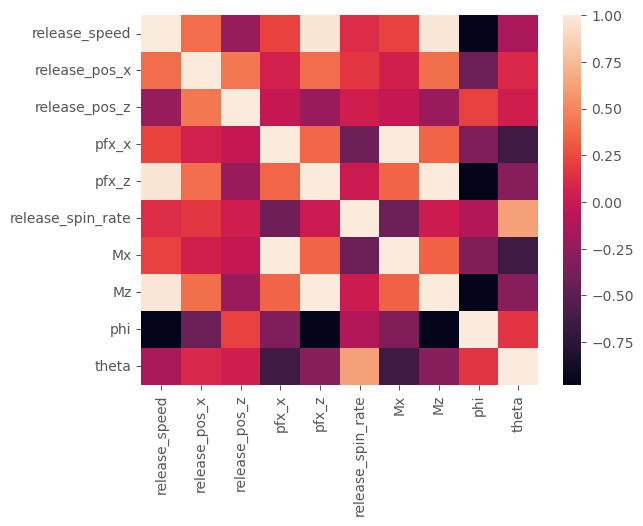

In [25]:
#heatmap seeing lots of correlations
sns.heatmap(corr1)

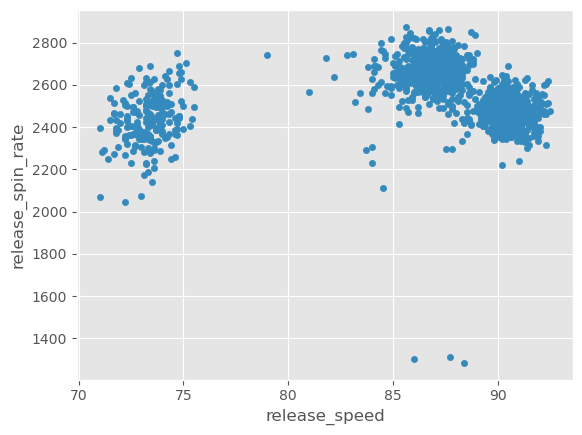

In [26]:
#checking correlation between spin_rate and release_speed
spin_data.plot(kind='scatter',x='release_speed',y='release_spin_rate')
plt.show()

In [27]:
datacluster = spin_data[['release_speed', 'release_spin_rate','pfx_x','pfx_z', 'spin_axis', 'effective_speed'  ]].copy()
datacluster1 = datacluster.dropna()
datacluster1.mask(datacluster1.astype(object).eq('None')).dropna()
datacluster1 = datacluster1.loc[datacluster1['spin_axis'] > 10]
datacluster1

,release_speed,release_spin_rate,pfx_x,pfx_z,spin_axis,effective_speed
0,90.5,2492.0,-0.45,1.68,195,89.9
1,91.1,2420.0,-0.12,1.61,184,91.1
2,89.7,2525.0,-0.14,1.42,186,89.2
3,90.3,2424.0,-0.32,1.80,190,89.3
4,90.1,2353.0,-0.32,1.51,192,90.2
5,90.7,2482.0,-0.28,1.50,191,91.1
6,90.8,2491.0,-0.01,1.76,180,90.2
7,86.9,2675.0,-0.39,0.46,220,86.6
8,86.5,2728.0,-0.65,0.77,220,85.4
9,85.7,2683.0,-0.57,0.49,229,84.5


In [28]:
scaler = StandardScaler()
scaledcluster = scaler.fit_transform(datacluster1)
scaledcluster = pd.DataFrame(scaledcluster)
scaledcluster

,0,1,2,3,4,5
0,0.693818,-0.332537,-0.911751,0.856529,-0.430489,0.637623
1,0.796123,-0.840474,0.502545,0.787521,-0.622958,0.834995
2,0.557411,-0.099732,0.416830,0.600214,-0.587964,0.522490
3,0.659716,-0.812255,-0.354604,0.974829,-0.517975,0.538937
4,0.625615,-1.313137,-0.354604,0.688938,-0.482981,0.686966
5,0.727920,-0.403083,-0.183174,0.679080,-0.500478,0.834995
6,0.744971,-0.339591,0.973977,0.935396,-0.692947,0.686966
7,0.079988,0.958470,-0.654606,-0.346182,0.006941,0.094851
8,0.011785,1.332368,-1.768900,-0.040575,0.006941,-0.102521
9,-0.124622,1.014907,-1.426040,-0.316607,0.164415,-0.250549


## Determining Pitches Through Clustering
To be able to achieve the best predictions for strategy, first pitch movement data must be tracked and clustered to create organic pitch types because it has been estimated that 10% of all pitches are mislabeled by Statcast. For this, I will try a few clustering algorithms, including K-means, DBSCAN, and Gaussian Mixture Model.

To achieve the goal, I used a python package named Pybaseball to obtain all of the data I needed. This came in the form of 3 different called data sets, one which would be the most effective for clustering pitches together, one which gives general pitch data about a pitcher, and a third which does the same for the batter. First, I was able to estimate the number of unique pitches a pitcher may throw using the elbow method, which compares a sum of squares to values of K. This allowed me to look for an ‘elbow’, which is the location on the graph where the line begins running parallel to the x-axis. From there, I tested K-means, TSNE, Agglomerative, Gaussian Mixture, and DBSCAN clustering.


C:\Users\erikw\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\erikw\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\erikw\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\erikw\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of

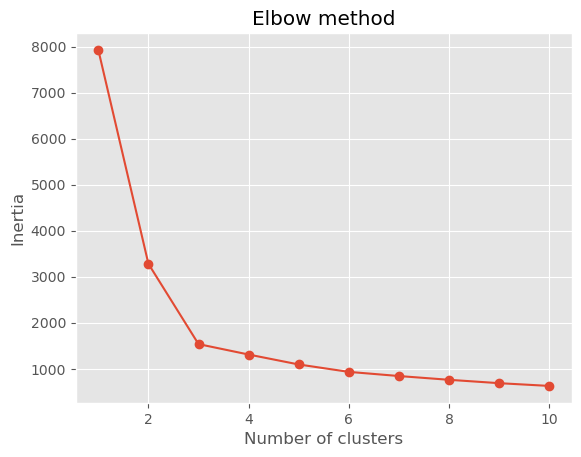

In [29]:
inertias = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(scaledcluster)
    inertias.append(kmeans.inertia_)
    
plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

k-means compares values to centroids

In [30]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(scaledcluster)
scaledcluster['kmeans_3'] = kmeans.labels_

C:\Users\erikw\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


0.6874202532747692


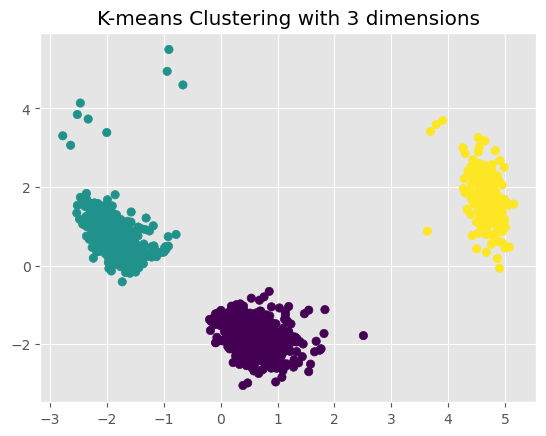

In [58]:
pca_num_components = 2
scaledcluster.columns = scaledcluster.columns.astype(str)
reduced_data = PCA(n_components=pca_num_components).fit_transform(scaledcluster)
results = pd.DataFrame(reduced_data,columns=['pca1','pca2'])
ss = silhouette_score(scaledcluster, kmeans.labels_)
print(ss)
plt.scatter(x="pca1", y="pca2", c=scaledcluster['kmeans_3'], data=results)
plt.title('K-means Clustering with 3 dimensions')
plt.show()

Alternative to PCA, nonlinear dimensionality reduction

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1321 samples in 0.004s...
[t-SNE] Computed neighbors for 1321 samples in 0.040s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1321
[t-SNE] Computed conditional probabilities for sample 1321 / 1321
[t-SNE] Mean sigma: 0.237323
[t-SNE] KL divergence after 250 iterations with early exaggeration: 59.135628
[t-SNE] KL divergence after 1000 iterations: 0.634603
0.6552192


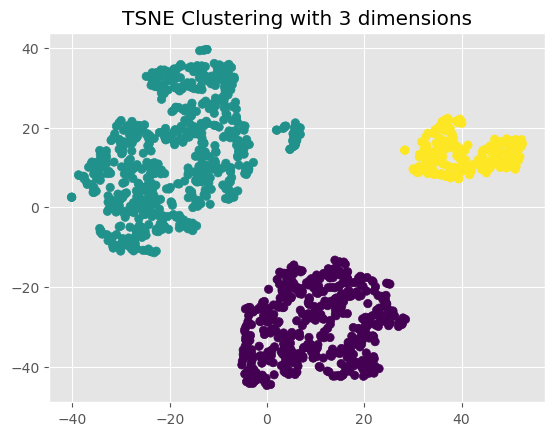

1    654
0    468
2    199
Name: kmeans_3, dtype: int64


In [59]:
tsne = TSNE(n_components=2,verbose=1, perplexity=30, n_iter=1000)
proj = tsne.fit_transform(scaledcluster.values)

tsneresults = pd.DataFrame(proj, columns=['tsne1','tsne2'])

ss = silhouette_score(proj, kmeans.labels_)
print(ss)
plt.scatter(x="tsne1", y="tsne2", c=scaledcluster['kmeans_3'], data=tsneresults)
plt.title('TSNE Clustering with 3 dimensions')
plt.show()
cluster_counts = scaledcluster['kmeans_3'].value_counts()
print(cluster_counts)

hierarchical clustering

In [33]:
hc = AgglomerativeClustering(n_clusters = 3)
hc.fit(scaledcluster.values)
scaledcluster['hc_3'] = hc.labels_

0.6874202532747692


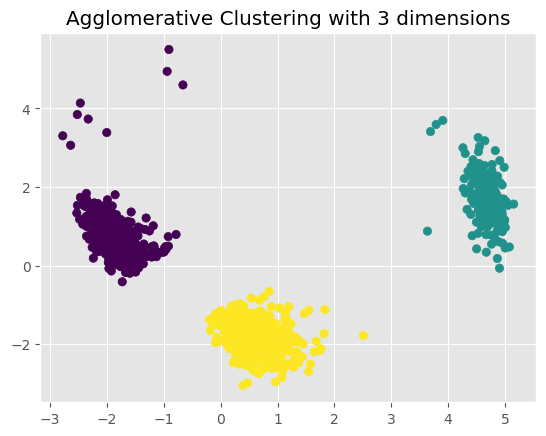

In [60]:
pca_num_components = 2

reduced_data = PCA(n_components=pca_num_components).fit_transform(scaledcluster.values)
results = pd.DataFrame(reduced_data,columns=['pca1','pca2'])
ss = silhouette_score(scaledcluster.values, hc.labels_)
print(ss)
plt.scatter(x="pca1", y="pca2", c=scaledcluster['hc_3'], data=results)
plt.title('Agglomerative Clustering with 3 dimensions')
plt.show()

Similar to k-means, but handles oblongs better

In [35]:
gmm = GaussianMixture(n_components=3)
gmmlabels = gmm.fit_predict(scaledcluster.values)
scaledcluster['gmm_3'] = gmmlabels

0.6874202532747692


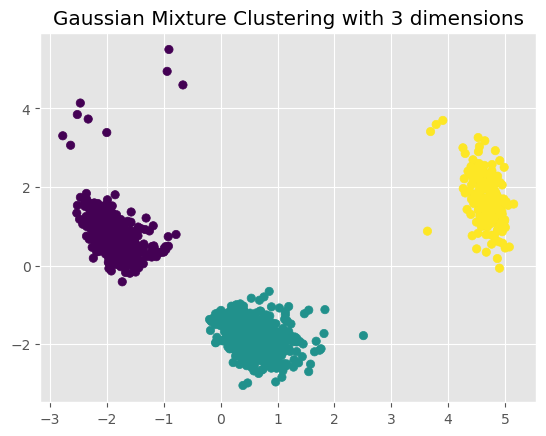

In [61]:
pca_num_components = 2

reduced_data = PCA(n_components=pca_num_components).fit_transform(scaledcluster.values)
results = pd.DataFrame(reduced_data,columns=['pca1','pca2'])
ss = silhouette_score(scaledcluster.values, gmmlabels)
print(ss)
plt.scatter(x="pca1", y="pca2", c=scaledcluster['gmm_3'], data=results)
plt.title('Gaussian Mixture Clustering with 3 dimensions')
plt.show()

Finds dense regions surrounded by low density

In [37]:
dbscan = DBSCAN(eps=.8, min_samples=10)
dbscan.fit(scaledcluster.values)
scaledcluster['dbscan_3'] = dbscan.labels_

0.6888745383332268


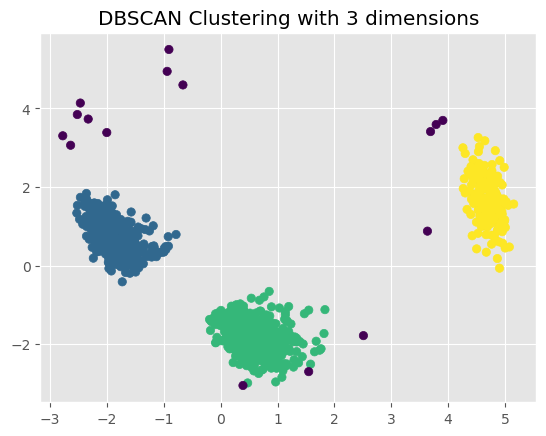

In [62]:
pca_num_components = 2

reduced_data = PCA(n_components=pca_num_components).fit_transform(scaledcluster.values)
results = pd.DataFrame(reduced_data,columns=['pca1','pca2'])
ss = silhouette_score(scaledcluster.values, dbscan.labels_)
print(ss)
plt.scatter(x="pca1", y="pca2", c=scaledcluster['dbscan_3'], data=results)
plt.title('DBSCAN Clustering with 3 dimensions')
plt.show()

## Clustering Results


|  | K-means | TSNE | Agglomerative | GMM | DBSCAN | 
| --- | --- | --- | --- | --- | --- |
| Silhouette Score | .687 | .655 | .687 | .687 | .689 | 

Unfortunately, the testing and utilization of clustering was cut short due to source data errors with pybaseball. (If you'd like to see an example of this error, use the name 'Justin Verlander' as an example). But, in the testing that was done, I was first able to use what is called an elbow chart to make suggestions on the number of pitches clusters to expect on the data. This is done by looking for the point where the line begins to run parallel to the x-axis. After that, I was able to utilize 5 different methods of clustering and evaluate them using the silhouette score. The silhouette score is an ideal metric because it gives a score of just how tightly packed each point is with other points. Through the testing, each model showed promise, but unfortunately, due to the lack of data, this potential boost to the accuracy of the pitch strategy optimizer is unable to be used.

## Pitch Strategy Prediction
Here, the functions dedicated to trying to obtain the optimal pitch strategy will be below.  

The final model in answering the question of the most ideal strategy for baseball pitchers is a regression model. This is not the model I expected to be best for the task, but as I looked at the best way to weigh the failure of a batter and success of a pitcher, I quickly found that the results were going to be continuous. The idea of classifying a best pitch or worst pitch became illogical as each of those can vary so widely depending on the batter, pitcher, and overall situation. 


In [39]:
#function defined to allow input of both player names, then have their id returned
def get_player_id(pitcher_name, batter_name):
    
    #split pitcher's name, then put split name into pybaseball's id lookup function
    first_name_pitcher, last_name_pitcher = pitcher_name.split(' ',1)
    first_name_pitcher = first_name_pitcher    
    last_name_pitcher = last_name_pitcher   
    get_id_pitcher = playerid_lookup(last_name_pitcher,first_name_pitcher)
    
    #split batter's name, then put split name into pybaseball's id lookup function
    first_name_batter, last_name_batter = batter_name.split(' ',1)
    first_name_batter = first_name_batter
    last_name_batter = last_name_batter
    get_id_batter = playerid_lookup(last_name_batter,first_name_batter)
    
    #the above is return in a bataframe, so grabbing just what I need
    #the .to_string(index=False) is used to get rid of duplicate index
    pitcher_id = get_id_pitcher['key_mlbam'].to_string(index=False)
    batter_id = get_id_batter['key_mlbam'].to_string(index=False)
    
    
    return pitcher_id, batter_id
    

### Data Acquisition

In [40]:
#defined function to use pitcher_id to grab data that will be use
def get_pitcher_data(pitcher_id):
    
    statcast_data_pitcher = statcast_pitcher('2018-07-01', '2022-10-31', player_id = pitcher_id)
    #take data and select desired columns
    pitcher_data = statcast_data_pitcher[['pitch_type', 'description', 'stand', 'p_throws', 'on_3b','on_2b','on_1b', 'zone', 'pitcher', 'balls', 'inning','strikes', 'outs_when_up', 'at_bat_number', 'pitch_number', 'delta_run_exp']].copy()    
    newpredictiondatapitcher = pitcher_data.copy()
    
    #only include pitch_type's that there are at least 100 of
    newpredictiondatapitcher = newpredictiondatapitcher[newpredictiondatapitcher.groupby('pitch_type').pitch_type.transform('count')>100].copy() 
    
    ### Key piece- create new column that is a sum of delta_run_exp based on what has been done in matching situations
    ### This is to create an expected run variance for a pitch situation
    groupbypitcher = newpredictiondatapitcher.groupby(['zone','pitch_type','balls','strikes'],as_index= False).delta_run_exp.sum()    
    sorted_pitcher_data = pd.merge(newpredictiondatapitcher,groupbypitcher, how='left', on=['zone','pitch_type','balls','strikes'])
    
    return sorted_pitcher_data

In [41]:
# mimics get_pitcher_data 
def get_batter_data(batter_id):
    
    statcast_data_batter = statcast_batter('2018-07-01', '2022-10-31', player_id = batter_id)
    batter_data = statcast_data_batter[['batter','description','zone','pitch_type', 'stand', 'p_throws', 'on_3b','on_2b','on_1b','outs_when_up','inning','balls','strikes','at_bat_number', 'pitch_number','delta_run_exp']].copy()
    newpredictiondatabatter = batter_data.copy()
    groupbybatter = newpredictiondatabatter.groupby(['zone','pitch_type','balls','strikes'],as_index= False).delta_run_exp.sum()
    sorted_batter_data = pd.merge(newpredictiondatabatter,groupbybatter, how='left', on=['zone','pitch_type','balls','strikes'])
    
    return sorted_batter_data

### Data Preperation

In [42]:
#most data cleaning in this function
def data_prep(sorted_pitcher_data, sorted_batter_data):
    
    
    # unique = sorted_pitcher_data.pitch_type.unique()
    
    #the next four lines take the most common listed hand thrown with for a pitcher and batting stance for a 
    #batter, then compare them to only keep data for the correct throwing hand/ batter stance matchup    
    most_common_p_throws_pitcher = sorted_pitcher_data['p_throws'].mode().iloc[0]   
    sorted_batter_data = sorted_batter_data[sorted_batter_data['p_throws'] == most_common_p_throws_pitcher]
    most_common_stand_batter = sorted_batter_data['stand'].mode().iloc[0]
    sorted_pitcher_data = sorted_pitcher_data[sorted_pitcher_data['stand'] == most_common_stand_batter]
    
    #drop pitch_type values that are null
    sorted_pitcher_data = sorted_pitcher_data.dropna(subset=['pitch_type'])
    sorted_batter_data = sorted_batter_data.dropna(subset=['pitch_type'])
    
    # As seen in data exploration, batters face more pitches than most pitchers throw. We only care about values where 
    # they're seen in both pitcher and batter data as we'll never suggest a pitch that a pitcher doesn't throw
    i = set(sorted_pitcher_data['pitch_type']) & set(sorted_batter_data['pitch_type'])
    combined_data = pd.concat([sorted_pitcher_data[sorted_pitcher_data['pitch_type'].isin(i)], sorted_batter_data[sorted_batter_data['pitch_type'].isin(i)]]).sort_values('pitch_type')
    
    
    
    
    #replace null values with 0, reset the index
    combined_data.replace(np.nan,0)
    combined_data = combined_data.fillna(0)
    combined_data = combined_data.reset_index(drop=True)
    
    #drop columns that aren't needed anymore
    combined_data.drop(columns=['description', 'p_throws','stand'], inplace=True)
    
    #we will need pitch_type to be numerical
    combined_data.pitch_type = pd.Categorical(combined_data.pitch_type)
    combined_data['pitch_code'] = combined_data.pitch_type.cat.codes
    
    combined_data['previous_pitch'] = None
    for index, row in combined_data.iterrows():
        if row['pitch_number'] > 1:
            previous_row = combined_data.loc[
                (combined_data['at_bat_number'] == row['at_bat_number']) & 
                (combined_data['pitch_number'] == row['pitch_number'] - 1)
            ]
            if not previous_row.empty:
                combined_data.at[index, 'previous_pitch'] = previous_row['pitch_code'].iloc[0]
              
    combined_data['previous_pitch'] = combined_data['previous_pitch'].fillna(9)
    print(combined_data['previous_pitch'].value_counts())
    #map pitch_type so that when the numerical value is used later, we can call pitch_type
    pitch_mapping = dict(zip(combined_data['pitch_code'], combined_data['pitch_type']))
    
    'at_bat_number', 'pitch_number',
    
    #currently these columns have player ids in them if a player is on base, I just want 1 or 0
    combined_data['on_1b'] = combined_data['on_1b'].where(combined_data['on_1b'] <= 1, 1)
    combined_data['on_2b'] = combined_data['on_2b'].where(combined_data['on_2b'] <= 1, 1)
    combined_data['on_3b'] = combined_data['on_3b'].where(combined_data['on_3b'] <= 1, 1)
        
    #drop pitch_type
    combined_data.drop(columns=['pitch_type'], inplace=True)
    
    #convert values to integers
    combined_data['batter'] = combined_data['batter'].astype(int)
    combined_data['zone'] = combined_data['zone'].astype(int)
    combined_data['on_3b'] = combined_data['on_3b'].astype(int)
    combined_data['on_2b'] = combined_data['on_2b'].astype(int)
    combined_data['on_1b'] = combined_data['on_1b'].astype(int)
    combined_data['inning'] = combined_data['inning'].astype(int)
    combined_data['pitcher'] = combined_data['pitcher'].astype(int)
    
    ### Multiply by 1000 because I need integers and delta_run_exp is a decimal
    combined_data = combined_data.multiply(1000)
    
    #now convert these to int
    combined_data['delta_run_exp_x'] = combined_data['delta_run_exp_x'].astype(int)
    combined_data['delta_run_exp_y'] = combined_data['delta_run_exp_y'].astype(int)
    
    return combined_data, pitch_mapping

### Data Preprocessing

In [43]:
#defining a function to encode
def data_preprocessing(combined_data):
    
    #label encoding values that are categorical
    label_encoder = LabelEncoder()
    #ordinal encoding values that have an order
    ordinal_encoder = OrdinalEncoder()
    combined_data['pitch_type_encoded'] = label_encoder.fit_transform(combined_data['pitch_code'])
    combined_data['previous_pitch_encoded'] = label_encoder.fit_transform(combined_data['previous_pitch'])
    combined_data['zone_encoded'] = label_encoder.fit_transform(combined_data['zone'])
    combined_data['on_3b_encoded'] = label_encoder.fit_transform(combined_data['on_3b'])
    combined_data['on_2b_encoded'] = label_encoder.fit_transform(combined_data['on_2b'])
    combined_data['on_1b_encoded'] = label_encoder.fit_transform(combined_data['on_1b'])
    combined_data['inning_encoded'] = ordinal_encoder.fit_transform(combined_data[['inning']])
    combined_data['balls_encoded'] = ordinal_encoder.fit_transform(combined_data[['balls']])
    combined_data['strikes_encoded'] = ordinal_encoder.fit_transform(combined_data[['strikes']])
    combined_data['outs_encoded'] = ordinal_encoder.fit_transform(combined_data[['outs_when_up']])

    #defining features to be used later and the ultimate target
    features = ['on_3b_encoded', 'on_2b_encoded','on_1b_encoded','inning_encoded','outs_encoded', 'balls_encoded', 'strikes_encoded', 'zone_encoded', 'pitch_type_encoded','previous_pitch_encoded']
    target = 'delta_run_exp_y'
    
    return features, target, combined_data, ordinal_encoder

### Model Exploration

I chose to test multiple models to see if anything was standing out. For the best performing models, I used GridSearchCV to optimize the parameters.

In [108]:
#training model through randomforestregressor
def model_train(features, target, combined_data):
    
    #defining X, y and splitting data into training and test data
    X = combined_data[features]
    y = combined_data[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    #training the model
    model = RandomForestRegressor(n_estimators = 200, max_features = 1.0, max_depth = 20, random_state = 42)
    model.fit(X_train, y_train)
    
    #model score is essentially r^2
    print(model.score(X_test,y_test))
    
    
    return features, target, model, y_test, X_test
    

In [109]:
#testing xgbregressor
def model_train1(features, target, combined_data):
   
    
    X = combined_data[features]
    y = combined_data[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
      
    model1 = xgb.XGBRegressor()
    model1.fit(X_train, y_train)
    print(model1.score(X_test,y_test))
    
    
    return features, target, model1, y_test, X_test

In [110]:
# testing an ANN
def model_train2(features, target, combined_data):
    
    X = combined_data[features]
    y = combined_data[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    #tested many different hidden layers
    model2 = Sequential()
    model2.add(Dense(units=128, activation='relu', input_dim=X_train.shape[1]))   
    model2.add(Dense(units=64, activation='relu'))
    model2.add(Dense(units=32, activation='softmax'))
    model2.add(Dense(units=1))  # Output layer

    #adam optimizer
    opt = Adam(learning_rate=0.01)
    
    #compile and train, put verbose at 0 for this version to limit output
    model2.compile(loss='mean_squared_error', optimizer=opt)
    model2.fit(X_train, y_train, epochs=60, batch_size=64, verbose=0)
    
    

    return features, target, model2, y_test, X_test

In [111]:
# testing linear regression
def model_train3(features, target, combined_data):
    
    X = combined_data[features]
    y = combined_data[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    #create model and train
    model3 = LinearRegression()
    model3.fit(X_train, y_train)
    print(model3.score(X_test,y_test))
    

    return features, target, model3, y_test, X_test

In [112]:
#testing lasso regression, values are essentially pulled towards mean
def model_train4(features, target, combined_data):

    X = combined_data[features]
    y = combined_data[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    #alpha is a penalty, limit overfitting
    model4 = Lasso(alpha=1.0)
    model4.fit(X_train, y_train)
    
    print(model4.score(X_test,y_test))
   

    return features, target, model4, y_test, X_test

In [113]:
#alternative model to xgboost
def model_train5(features, target, combined_data):
      
    
    X = combined_data[features]
    y = combined_data[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
    #parameters chosen through gridsearchcv   
    model5 = CatBoostRegressor(iterations = 500, learning_rate = .04, depth = 9, loss_function = 'RMSE', eval_metric = 'RMSE', metric_period = 200, od_type ='Iter', od_wait = 20)  # Adjust parameters as needed
    model5.fit(X_train, y_train)
    
    print(model5.score(X_test,y_test))
    

    return features, target, model5, y_test, X_test

In [114]:
'''from sklearn.model_selection import GridSearchCV
    X = combined_data[features]
    y = combined_data[target]
    
    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    parameters = {'depth'         : [7,8,9, 10,11,12],
                 'learning_rate' : [.02,.04,.1,.3,.5,.7,.9],
                  'iterations'    : [200,300,400,500,600]
                 }
    
    # Create the CatBoost Regression model
    model5 = CatBoostRegressor()  # Adjust parameters as needed
    model5 = GridSearchCV(estimator=model5, param_grid = parameters, cv = 3, n_jobs=-1)
    model5.fit(X_train, y_train)
    # Train the model
    #model5.fit(X_train, y_train)
    
    print(" Results from Grid Search " )
    print("\n The best estimator across ALL searched params:\n",model5.best_estimator_)
    print("\n The best score across ALL searched params:\n",model5.best_score_)
    print("\n The best parameters across ALL searched params:\n",model5.best_params_)
    '''

'from sklearn.model_selection import GridSearchCV\n    X = combined_data[features]\n    y = combined_data[target]\n    \n    # Train-Test Split\n    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)\n    parameters = {\'depth\'         : [7,8,9, 10,11,12],\n                 \'learning_rate\' : [.02,.04,.1,.3,.5,.7,.9],\n                  \'iterations\'    : [200,300,400,500,600]\n                 }\n    \n    # Create the CatBoost Regression model\n    model5 = CatBoostRegressor()  # Adjust parameters as needed\n    model5 = GridSearchCV(estimator=model5, param_grid = parameters, cv = 3, n_jobs=-1)\n    model5.fit(X_train, y_train)\n    # Train the model\n    #model5.fit(X_train, y_train)\n    \n    print(" Results from Grid Search " )\n    print("\n The best estimator across ALL searched params:\n",model5.best_estimator_)\n    print("\n The best score across ALL searched params:\n",model5.best_score_)\n    print("\n The best parameters across AL

In [115]:
#testing gradient boosting regressor
def model_train6(features, target, combined_data):

    X = combined_data[features]
    y = combined_data[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    
    model6 = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
    model6.fit(X_train, y_train)
    
    print(model6.score(X_test,y_test))
    

    return features, target, model6, y_test, X_test

### Model Prediction

Below all of the models are used to make predictions and are evaluated. I determined that the best approach to evaluate both the success of the pitcher and the failure of the batter simultaneously was by using a shared statistic for the appropriate matchups. Because the idea of choosing a single best pitch on an island without feedback to suggest what would be expected in other situations felt so wrong, I decided to incorporate all possible combinations of situations and let the models determine how they all would perform. This allowed for the ideal heatmap as it gives information for all surrounding data, allowing the end-user to make a more informed decision

In [120]:
#This is essentially the predictor function, for this, I kept all models
def get_best_zone_and_pitch_type(model, model1, model2, model3, model4, model5, model6, features, ordinal_encoder, combined_data, balls_encoded, strikes_encoded, on_3b_encoded, on_2b_encoded, on_1b_encoded, inning_encoded, outs_encoded, y_test, X_test, pitch_mapping):
    # Create a dataframe with all possible combinations of zone and pitch_type
    
    #need number of pitches to make possible_combinations variable
    count = combined_data.pitch_type_encoded.nunique()
    
    #possible combinations is created to denote the number of values and particular situation for each prediction
    possible_combinations = pd.DataFrame({
        
        'pitch_type_encoded': np.tile(np.arange(0, count), 13),
        'balls_encoded': [balls_encoded] * 13 * count,
        'strikes_encoded': [strikes_encoded] * 13 * count,
        'zone_encoded': np.repeat(np.arange(1, 14), count),
        'on_3b_encoded': [on_3b_encoded] * 13 * count,
        'on_2b_encoded': [on_2b_encoded] * 13 * count,
        'on_1b_encoded': [on_1b_encoded] * 13 * count,
        'inning_encoded': [inning_encoded] * 13 * count,
        'outs_encoded': [outs_encoded] * 13 * count,
        'previous_pitch_encoded': np.tile(np.arange(0, count), 13)
    })
    
    #Running each model for the possible combinations
    predictions = model.predict(possible_combinations[features])
    predictions1 = model1.predict(possible_combinations[features])
    predictions2 = model2.predict(possible_combinations[features])
    predictions3 = model3.predict(possible_combinations[features])
    predictions4 = model4.predict(possible_combinations[features])
    predictions5 = model5.predict(possible_combinations[features])
    predictions6 = model6.predict(possible_combinations[features])
    
    #making y_pred values for each model
    y_pred = model.predict(X_test[features])
    y_pred1 = model1.predict(X_test[features])
    y_pred2 = model2.predict(X_test[features])
    y_pred3 = model3.predict(X_test[features])
    y_pred4 = model4.predict(X_test[features])
    y_pred5 = model5.predict(X_test[features])
    y_pred6 = model6.predict(X_test[features])
    
    #divide each by 1000 to bring them back down to real numbers
    y_test = y_test.div(1000)
    y_pred = np.divide(y_pred, 1000)
    y_pred1 = np.divide(y_pred1, 1000)
    y_pred2 = np.divide(y_pred2, 1000)
    y_pred3 = np.divide(y_pred3, 1000)
    y_pred4 = np.divide(y_pred4, 1000)
    y_pred5 = np.divide(y_pred5, 1000)
    y_pred6 = np.divide(y_pred6, 1000)
    
    #each of these sets are going to be used to help evaluate the accuracy of the regression models
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Root Mean Squared Error: {rmse:.2f}")
    print(f"Mean Absolute Error: {mae:.2f}")
    
    mse1 = mean_squared_error(y_test, y_pred1)
    rmse1 = np.sqrt(mse1)
    mae1 = mean_absolute_error(y_test, y_pred1)

    print(f"Mean Squared Error: {mse1:.2f}")
    print(f"Root Mean Squared Error: {rmse1:.2f}")
    print(f"Mean Absolute Error: {mae1:.2f}")
    
    mse2 = mean_squared_error(y_test, y_pred2)
    rmse2 = np.sqrt(mse2)
    mae2 = mean_absolute_error(y_test, y_pred2)

    print(f"Mean Squared Error: {mse2:.2f}")
    print(f"Root Mean Squared Error: {rmse2:.2f}")
    print(f"Mean Absolute Error: {mae2:.2f}")
    
    mse3 = mean_squared_error(y_test, y_pred3)
    rmse3 = np.sqrt(mse3)
    mae3 = mean_absolute_error(y_test, y_pred3)

    print(f"Mean Squared Error: {mse3:.2f}")
    print(f"Root Mean Squared Error: {rmse3:.2f}")
    print(f"Mean Absolute Error: {mae3:.2f}")
    
    mse4 = mean_squared_error(y_test, y_pred4)
    rmse4 = np.sqrt(mse4)
    mae4 = mean_absolute_error(y_test, y_pred4)

    print(f"Mean Squared Error: {mse4:.2f}")
    print(f"Root Mean Squared Error: {rmse4:.2f}")
    print(f"Mean Absolute Error: {mae4:.2f}")
    
    mse5 = mean_squared_error(y_test, y_pred5)
    rmse5 = np.sqrt(mse5)
    mae5 = mean_absolute_error(y_test, y_pred5)

    print(f"Mean Squared Error: {mse5:.2f}")
    print(f"Root Mean Squared Error: {rmse5:.2f}")
    print(f"Mean Absolute Error: {mae5:.2f}")
    
    mse6 = mean_squared_error(y_test, y_pred6)
    rmse6 = np.sqrt(mse6)
    mae6 = mean_absolute_error(y_test, y_pred6)

    print(f"Mean Squared Error: {mse6:.2f}")
    print(f"Root Mean Squared Error: {rmse6:.2f}")
    print(f"Mean Absolute Error: {mae6:.2f}")
    
    
    #get the best index by finding the minimum value of delta_run_exp_y
    best_idx = np.argmin(predictions)
    
    #get the best zone and pitch_type based on the index above
    best_zone = possible_combinations.loc[best_idx, 'zone_encoded']
    best_pitch_type_encoded = possible_combinations.loc[best_idx, 'pitch_type_encoded']

    #just for plot
    y_actual = y_test  

    #scatter plot showing visually how well it has been predicted
    plt.figure(figsize=(8, 6))
    plt.scatter(y_actual, y_pred, color='blue', alpha=0.5)
    plt.title('Actual vs. Predicted Values')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.grid(True)
    plt.show()
     
    
    #get best by inverse_transforming the pitch type and then dividing by 1000, return pitch name also
    best_pitch_type = ordinal_encoder.inverse_transform(best_pitch_type_encoded.reshape(-1, 1))[0,0]
    best_pitch_type = int(best_pitch_type/1000)
    pitch_code = best_pitch_type
    pitch_type_associated = pitch_mapping[pitch_code]
    
    return predictions, best_zone, best_pitch_type, possible_combinations, pitch_type_associated

### Main Function
This function is dedicated to calling all other defined functions. Overall creating all of these functions was done to allow for the code to be adaptable and reuseable.

In [117]:
#main function that will take in form data on web app and then go through all the defined functions
#can easily remove models, but for testing, I will leave them
def main(pitcher_name, batter_name, balls_encoded, strikes_encoded, outs_encoded, on_3b_encoded, on_2b_encoded, on_1b_encoded, inning_encoded):
    pitcher_id, batter_id = get_player_id(pitcher_name, batter_name)
    sorted_pitcher_data = get_pitcher_data(pitcher_id)
    sorted_batter_data = get_batter_data(batter_id)
    combined_data, pitch_mapping = data_prep(sorted_pitcher_data, sorted_batter_data)
    features, target, combined_data, ordinal_encoder = data_preprocessing(combined_data)
    features, target, model, y_test, X_test = model_train(features, target, combined_data)
    features, target, model1, y_test, X_test = model_train1(features, target, combined_data)
    features, target, model2, y_test, X_test = model_train2(features, target, combined_data)
    features, target, model3, y_test, X_test = model_train3(features, target, combined_data)
    features, target, model4, y_test, X_test = model_train4(features, target, combined_data)
    features, target, model5, y_test, X_test = model_train5(features, target, combined_data)
    features, target, model6, y_test, X_test = model_train6(features, target, combined_data)
    predictions, best_zone, best_pitch_type, possible_combinations, pitch_type_associated = get_best_zone_and_pitch_type(model, model1, model2, model3, model4, model5, model6, features, ordinal_encoder, combined_data, balls_encoded, strikes_encoded, on_3b_encoded, on_2b_encoded, on_1b_encoded, inning_encoded, outs_encoded, y_test, X_test, pitch_mapping)
    return predictions, best_zone, best_pitch_type, possible_combinations, pitch_type_associated

### Test Parameters
This just allows for testing when the input isn't from a form on a web app

Gathering Player Data
Gathering Player Data
0    4238
9    2513
1    2130
2     541
3      21
Name: previous_pitch, dtype: int64
0.6494962656220302
0.6679155199469882
0.1279287260965325
0.12791713585891518
0:	learn: 2004.3424089	total: 2.53ms	remaining: 1.26s
200:	learn: 1111.6123168	total: 375ms	remaining: 558ms
400:	learn: 996.6547926	total: 745ms	remaining: 184ms
499:	learn: 962.3539758	total: 925ms	remaining: 0us
0.6802954932587362
0.5488883293016968
60/60 [==============================] - 0s 786us/step
Mean Squared Error: 1.43
Root Mean Squared Error: 1.20
Mean Absolute Error: 0.70
Mean Squared Error: 1.36
Root Mean Squared Error: 1.16
Mean Absolute Error: 0.81
Mean Squared Error: 4.09
Root Mean Squared Error: 2.02
Mean Absolute Error: 1.48
Mean Squared Error: 3.56
Root Mean Squared Error: 1.89
Mean Absolute Error: 1.40
Mean Squared Error: 3.56
Root Mean Squared Error: 1.89
Mean Absolute Error: 1.40
Mean Squared Error: 1.31
Root Mean Squared Error: 1.14
Mean Absolute Error: 0.79


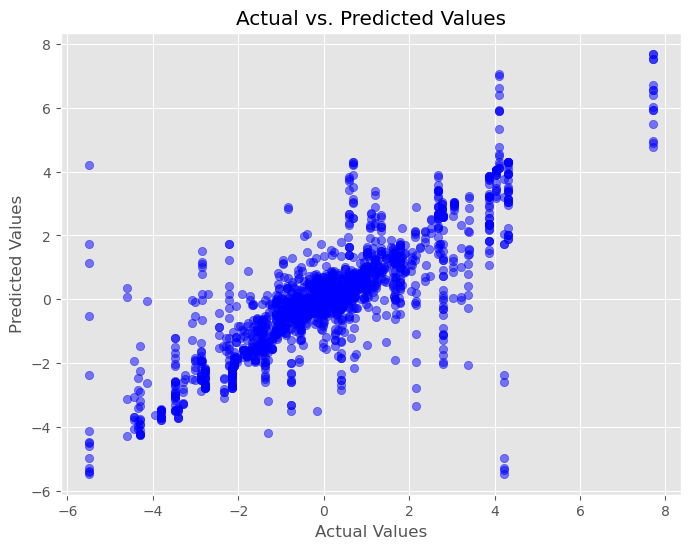

The best zone for the pitcher is: 1
The best pitch type for the pitcher is: 2 FF


In [121]:
# This is test usage. These values will come from the forms on the web app
#batter_id = 545361
#pitcher_id = 477132
pitcher_name = 'Justin Verlander'
batter_name = 'Nolan Arenado'
balls_encoded = 0
strikes_encoded = 0
inning_encoded = 2
outs_encoded = 1
on_3b_encoded = 0
on_2b_encoded = 0
on_1b_encoded = 1

#call main
predictions, best_zone, best_pitch_type, possible_combinations, pitch_type_associated = main(pitcher_name, batter_name, balls_encoded, strikes_encoded, outs_encoded, on_3b_encoded, on_2b_encoded, on_1b_encoded, inning_encoded)

#output
print(f"The best zone for the pitcher is: {best_zone}")
print(f"The best pitch type for the pitcher is: {best_pitch_type} {pitch_type_associated}")


### Heatmap
This is the primary visualization due to its common utilization in baseball visualization. I made the choice to only show the data for the pitches in the strikezone. The pitches outside the zone are never truly recommended by the algorithm, so this allows more focus on the prediction.

C:\Users\erikw\AppData\Local\Temp\ipykernel_2532\799361738.py:34: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


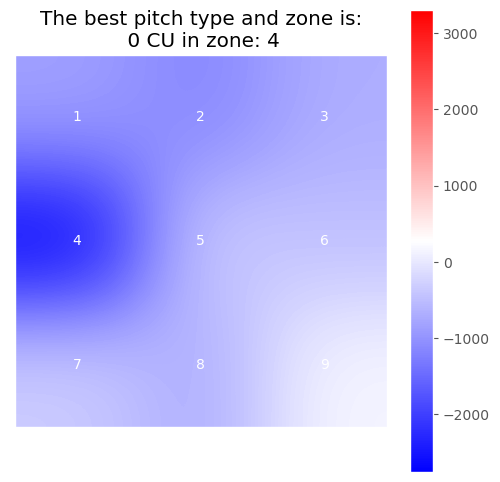

In [119]:

predictions = pd.DataFrame(predictions)

#calculate number of pitch types
total_groups = len(predictions) // 13

heatmap_data_list = []
#split data which was previously iterated by pitch type first
#now data will iterate by zone to allow heatmap
for value_idx in range(best_pitch_type, 9 * total_groups, total_groups):
    group_values = predictions.iloc[value_idx, 0] 
    heatmap_data_list.append(group_values)


heatmap_data = pd.Series(heatmap_data_list).values.reshape(3, 3)


plt.figure(figsize=(6, 6))
plt.imshow(heatmap_data, cmap='bwr', interpolation='gaussian', vmin=predictions.min(), vmax=predictions.max())
plt.grid(True, color='gray', linewidth=0.5, alpha=0.5)

# Loop to display numbers in the middle of each zone
for i in range(3):
    for j in range(3):
        plt.text(j, i, str(i*3 + j + 1), ha='center', va='center', color='white')

plt.xticks([])
plt.yticks([])

plt.colorbar()
plt.title(f"The best pitch type and zone is:\n {best_pitch_type} {pitch_type_associated} in zone: {best_zone}")
plt.show()


## Results

|  | Random Forest | XGBoost | ANN | Linear | Lasso | CatBoost | GradientBoost |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Model Score | .925 | .917 |  | .123 | .124 | .924 | .679 | 
| --- | --- | --- | --- | --- | --- | --- | --- |
| MSE | .41 | .45 | 5.49 | 4.73 | 4.73 | .41 | 1.73 | 
| --- | --- | --- | --- | --- | --- | --- | --- |
| RMSE | .64 | .67 | 2.34 | 2.17 | 2.17 | .64 | 1.32 | 
| --- | --- | --- | --- | --- | --- | --- | --- |
| MAE | .20 | .32 | 1.59 | 1.57 | 1.57 | .33 | .99 | 
| --- | --- | --- | --- | --- | --- | --- | --- |


### Results Discussion

In the table above, along with the heatmap, scatter plot, and predictions, we see the results for the pitch optimization strategy. Starting with the models assessed, we see that I chose 7 different regression models that were all using the features 'on_3b_encoded', 'on_2b_encoded','on_1b_encoded','inning_encoded','outs_encoded', 'balls_encoded', 'strikes_encoded', 'zone_encoded', 'pitch_type_encoded','previous_pitch_encoded'.

These features were chosen because in the exploratory analysis, it was found that they all have low correlation to each other and each should have an impact on when, where, and what pitch is thrown. These will all help to lead to the target, which is the statistic delta_run_exp, which is an incredibly powerful statistic used to assess the expected runs each pitch will lead to. For the purpose of this project, this statistic is perfect because it has negative values for a hitter, suggesting his failure, and negative values for a pitcher, suggesting he is less likely to give up a run.

So, realizing this was the perfect target, I looked at potential models and decided to try each and compare results. For any results that are close, I did run a GradientSearchCV to try to find the best parameters, but on multiple occasions found that the default parameters were the most consistent.

As seen in the chart above, the random forest regressor scored well across all metrics. I was particularly focused on RMSE and MAE because I felt as though they complimented each other well. RMSE has much heavier penalties for outliers, which can be very important in a situation like baseball, but, the simplicity of mean average error also is nice to see.

Moving on to the predictions, the output is simply the zone and pitch type combination that is likely to have the best result for the pitcher. While this is the primary result, the path to achieving it is done through having the model predicting the target value for every pitch and zone combination, then, finding the one that favored the pitcher the most, and returning that. The heatmap is returned showing the range of expected success for a the pitcher and hitter in each locaiton, which is important because in a realistic game, it is important to know where you'd like to 'miss'. Lastly, the scatter plot was created as a nice visual to quickly get the feel of how accurate the predictions have been. 

## Results Conclusion
Ultimately, I do feel as though my algorithm was able to do what I set out to do. With varying accuracy, but always showing at very least a strong correlation, it was able to show that the predicted values did match the test values. Baseball is a fickle sport, so I was never expecting to be able to predict this with 100% accuracy. Also, I absolutely expected some hitters or pitchers to be less predictable than others, so overall, I feel as though my results supported everything I did expect.